In [1]:
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import matplotlib.pyplot as plt

In [2]:
spark = SparkSession.builder.appName("Bus Arrival Prediction").getOrCreate()

In [3]:
bus_schedule = spark.read.parquet("Data/Processed/bus_schedule")
vehicle = pd.read_csv("Data/Processed/vehicle_clean.csv")
disruption = pd.read_csv("Data/Processed/disruption_clean.csv")

In [4]:
# DataSet Overview
print("BUS SCHEDULE DATASET")
print("Rows :", bus_schedule.count())
print("Columns :", len(bus_schedule.columns))
bus_schedule.printSchema()

BUS SCHEDULE DATASET
Rows : 5195977
Columns : 31
root
 |-- service_id: integer (nullable = true)
 |-- stop_id: string (nullable = true)
 |-- trip_id: string (nullable = true)
 |-- route_id: integer (nullable = true)
 |-- trip_headsign: string (nullable = true)
 |-- direction_id: integer (nullable = true)
 |-- shape_id: string (nullable = true)
 |-- wheelchair_accessible: integer (nullable = true)
 |-- agency_id: string (nullable = true)
 |-- route_short_name: string (nullable = true)
 |-- route_long_name: string (nullable = true)
 |-- route_type: integer (nullable = true)
 |-- arrival_time: string (nullable = true)
 |-- departure_time: string (nullable = true)
 |-- stop_sequence: integer (nullable = true)
 |-- pickup_type: integer (nullable = true)
 |-- drop_off_type: integer (nullable = true)
 |-- timepoint: integer (nullable = true)
 |-- stop_name: string (nullable = true)
 |-- stop_lat: double (nullable = true)
 |-- stop_lon: double (nullable = true)
 |-- wheelchair_boarding: intege

In [5]:
print("VEHICLE DATASET")
print(vehicle.shape)
vehicle.info()
vehicle.head()

VEHICLE DATASET
(27488, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27488 entries, 0 to 27487
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RecordedTime  27488 non-null  object 
 1   LineRef       27488 non-null  object 
 2   Operator      27488 non-null  object 
 3   VehicleRef    27488 non-null  object 
 4   Latitude      27488 non-null  float64
 5   Longitude     27488 non-null  float64
dtypes: float64(2), object(4)
memory usage: 1.3+ MB


,RecordedTime,LineRef,Operator,VehicleRef,Latitude,Longitude
0,2026-07-02 15:10:13+00:00,96A,A2BR,3303,51.981412,-0.233722
1,2026-07-02 17:33:39+00:00,16A,A2BR,3311,52.073968,0.008972
2,2026-07-02 18:12:15+00:00,811,A2BV,A2BV-24,53.368135,-3.069226
3,2026-07-02 19:16:10+00:00,1A,A2BV,A2BV-RE24_TDZ,53.365285,-3.065045
4,2026-07-02 17:11:17+00:00,106,A2BV,A2BV-YJ10_MHK,53.419548,-3.046595


In [6]:
print("DISRUPTION")
print(disruption.shape)
disruption.info()
disruption.head()

DISRUPTION
(374, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   CreationTime         374 non-null    object
 1   ParticipantRef       374 non-null    object
 2   Progress             374 non-null    object
 3   MiscellaneousReason  374 non-null    object
 4   Planned              374 non-null    bool  
 5   Summary              374 non-null    object
 6   Description          374 non-null    object
 7   EquipmentReason      374 non-null    object
dtypes: bool(1), object(7)
memory usage: 20.9+ KB


,CreationTime,ParticipantRef,Progress,MiscellaneousReason,Planned,Summary,Description,EquipmentReason
0,2024-08-30 09:07:04.813000+00:00,WestofEngland,open,roadworks,True,Live Traffic Update: York Road One Way Closure,Long term works - York Road is closed eastboun...,Unknown
1,2024-11-01 15:42:15.905000+00:00,WYCA,open,roadworks,True,"Horsforth Vale, Bletchley Avenue, Bletchley Ro...","Bletchley Avenue, Bletchley Road and Low Hall ...",Unknown
2,2025-03-06 09:16:59+00:00,WestofEngland,open,roadworks,False,Tower Road/Station Road,Due to Temporary Lights on the Junction of Tow...,Unknown
3,2025-03-28 11:17:43+00:00,WestofEngland,open,roadworks,True,"Road Closure: Victoria Street, Bristol","Victoria Street in Bristol City Centre, northb...",Unknown
4,2025-03-31 11:39:08+00:00,WestofEngland,open,Unknown,True,Stop closure: The Assembly Rooms,This stop will be closed for approximately 20 ...,repairWork


In [7]:
agency = spark.read.option("header", True).csv("Data/Raw/agency.txt")
agency.createOrReplaceTempView("agency")
routes = spark.read.option("header", True).csv("Data/Raw/routes.txt")
routes.createOrReplaceTempView("routes")

In [53]:
vehicle_with_agency = vehicle_spark.join(
    agency,
    upper(trim(vehicle_spark.Operator)) == upper(trim(agency.agency_noc)),
    "left"
)
matched = vehicle_with_agency.join(
    routes,
    (vehicle_with_agency.agency_id == routes.agency_id) &
    (upper(trim(vehicle_with_agency.LineRef)) == upper(trim(routes.route_short_name))),
    "inner"
).drop(routes.agency_id)   # <-- ADD THIS LINE

print("Matched:", matched.count(), "/ Total:", vehicle_spark.count())

Matched: 3768 / Total: 27488


# Descriptive Statistics

In [9]:
bus_schedule.describe().show()

+-------+------------------+--------------------+--------------------+------------------+------------------+-------------------+--------------------+---------------------+---------+------------------+---------------+------------------+------------+--------------+------------------+-------------------+--------------------+-------------------+---------------+------------------+-------------------+-------------------+------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+--------------------+--------------------+
|summary|        service_id|             stop_id|             trip_id|          route_id|     trip_headsign|       direction_id|            shape_id|wheelchair_accessible|agency_id|  route_short_name|route_long_name|        route_type|arrival_time|departure_time|     stop_sequence|        pickup_type|       drop_off_type|          timepoint|      stop_name|          stop_lat|           stop_lon|whe

In [10]:
vehicle.describe(include="all")

,RecordedTime,LineRef,Operator,VehicleRef,Latitude,Longitude
count,27488,27488,27488,27488,27488.000000,27488.000000
unique,18952,2329,365,25608,NaN,NaN
top,2026-07-03 01:21:09+00:00,1,TFLO,514,NaN,NaN
freq,40,470,7764,6,NaN,NaN
mean,NaN,NaN,NaN,NaN,52.072691,-1.116627
std,NaN,NaN,NaN,NaN,3.504955,1.470572
min,NaN,NaN,NaN,NaN,0.000000,-6.348000
25%,NaN,NaN,NaN,NaN,51.473102,-2.004849
50%,NaN,NaN,NaN,NaN,51.748725,-1.101638
75%,NaN,NaN,NaN,NaN,53.337765,-0.113958


In [11]:
disruption.describe(include="all")

,CreationTime,ParticipantRef,Progress,MiscellaneousReason,Planned,Summary,Description,EquipmentReason
count,374,374,374,374,374,374,374,374
unique,358,9,1,10,2,357,371,7
top,2025-06-24 09:39:50+00:00,TfGM,open,roadworks,True,Victoria - Tram Improvement Works,Due to an emergency road closure on Alan Turin...,Unknown
freq,5,117,374,197,298,4,2,279


In [12]:
# SQL views
routes = spark.read.option("header", True).csv("Data/Raw/routes.txt")
trips = spark.read.option("header", True).csv("Data/Raw/trips.txt")
stops = spark.read.option("header", True).csv("Data/Raw/stops.txt")
stop_times = spark.read.option("header", True).csv("Data/Raw/stop_times.txt")
calendar = spark.read.option("header", True).csv("Data/Raw/calendar.txt")

In [13]:
routes.createOrReplaceTempView("routes")
trips.createOrReplaceTempView("trips")
stops.createOrReplaceTempView("stops")
stop_times.createOrReplaceTempView("stop_times")
calendar.createOrReplaceTempView("calendar")
bus_schedule.createOrReplaceTempView("bus_schedule")

# Spark SQL queries

In [14]:
#Top 10 Routes by Number of Stop Records
top_routes = spark.sql("""
SELECT
route_short_name,
COUNT(*) AS total_trips
FROM bus_schedule
GROUP BY route_short_name
ORDER BY total_trips DESC
LIMIT 10
""")
top_routes.show()
top_routes = top_routes.toPandas()

+----------------+-----------+
|route_short_name|total_trips|
+----------------+-----------+
|               1|      95727|
|             192|      71200|
|               7|      69971|
|              10|      65649|
|              17|      64612|
|              82|      63217|
|              41|      62135|
|               5|      59735|
|             10A|      58653|
|              61|      57748|
+----------------+-----------+



In [43]:
top_stops = spark.sql("""
SELECT
s.stop_name,
COUNT(*) AS total_visits
FROM stop_times st
JOIN stops s
ON st.stop_id=s.stop_id
GROUP BY s.stop_name
ORDER BY total_visits DESC
LIMIT 10
""")
top_stops.show()

+--------------------+------------+
|           stop_name|total_visits|
+--------------------+------------+
|         Bus Station|       24404|
|  Piccadilly Gardens|       17344|
|    Dickinson Street|        9958|
|    Charlotte Street|        9345|
|               Tesco|        8970|
|Royal Liverpool U...|        8943|
|Queen Square Bus ...|        8483|
|     Railway Station|        7933|
|           Morrisons|        7815|
|         Post Office|        7785|
+--------------------+------------+



In [16]:
spark.sql("""
SELECT
route_short_name,
COUNT(*) AS total_trips
FROM bus_schedule
GROUP BY route_short_name
ORDER BY total_trips DESC
LIMIT 10
""").show()

+----------------+-----------+
|route_short_name|total_trips|
+----------------+-----------+
|               1|      95727|
|             192|      71200|
|               7|      69971|
|              10|      65649|
|              17|      64612|
|              82|      63217|
|              41|      62135|
|               5|      59735|
|             10A|      58653|
|              61|      57748|
+----------------+-----------+



In [17]:
#agency id with the services
spark.sql("""
SELECT
agency_id,
COUNT(*) AS total_services
FROM bus_schedule
GROUP BY agency_id
ORDER BY total_services DESC
LIMIT 10
""").show()

+---------+--------------+
|agency_id|total_services|
+---------+--------------+
|  OP13829|        714567|
|  OP10924|        692824|
|    OP258|        691366|
|    OP539|        641102|
|  OP11122|        487305|
|    OP260|        406458|
|    OP302|        272943|
|    OP288|        194088|
|  OP11023|        144167|
|    OP278|        129992|
+---------+--------------+



In [18]:
# Wheel chair access
spark.sql("""
SELECT
wheelchair_accessible,
COUNT(*) AS total
FROM bus_schedule
GROUP BY wheelchair_accessible
""").show()

+---------------------+-------+
|wheelchair_accessible|  total|
+---------------------+-------+
|                    0|5195977|
+---------------------+-------+



In [19]:
# weekly report
days = spark.sql("""
SELECT
SUM(monday) AS Monday,
SUM(tuesday) AS Tuesday,
SUM(wednesday) AS Wednesday,
SUM(thursday) AS Thursday,
SUM(friday) AS Friday,
SUM(saturday) AS Saturday,
SUM(sunday) AS Sunday
FROM bus_schedule
""")
days.show()

+-------+-------+---------+--------+-------+--------+------+
| Monday|Tuesday|Wednesday|Thursday| Friday|Saturday|Sunday|
+-------+-------+---------+--------+-------+--------+------+
|1947890|1948989|  1949112| 1950947|1956969| 1732849|958490|
+-------+-------+---------+--------+-------+--------+------+



# Visualization


In [20]:
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

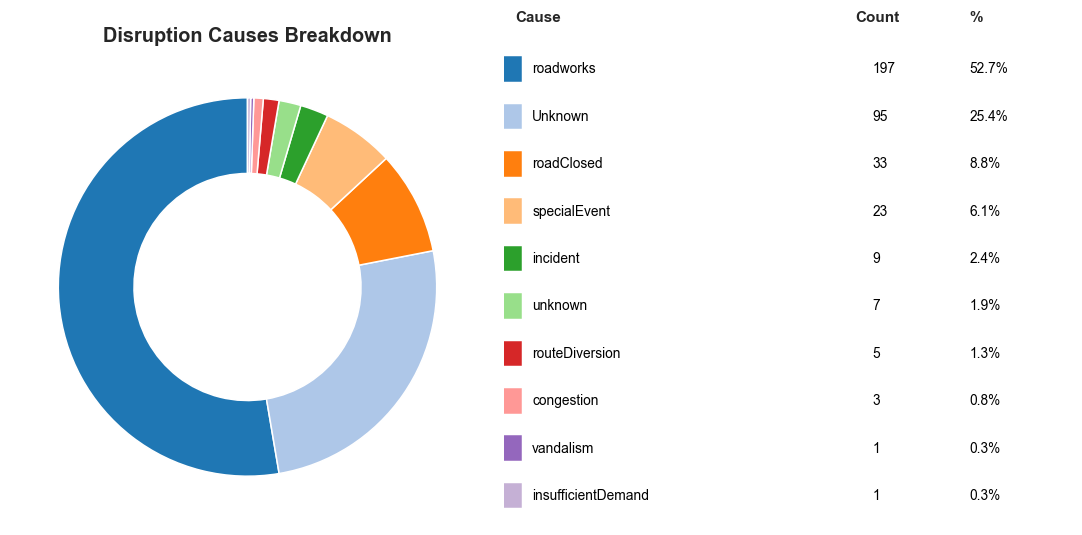

In [32]:
reason_counts = disruption["MiscellaneousReason"].value_counts()
percentages = (reason_counts / reason_counts.sum() * 100).round(1)
n = len(reason_counts)

colors = sns.color_palette("tab20", n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={"width_ratios": [1, 1.2]})

ax1.pie(
    reason_counts.values,
    startangle=90,
    colors=colors,
    wedgeprops={"width": 0.4, "edgecolor": "white"}
)
ax1.set_title("Disruption Causes Breakdown", fontsize=13)

# --- table side ---
ax2.axis("off")
ax2.set_xlim(0, 1)
ax2.set_ylim(0, n)
ax2.invert_yaxis()

# header
ax2.text(0.02, -0.6, "Cause", fontsize=10, fontweight="bold")
ax2.text(0.62, -0.6, "Count", fontsize=10, fontweight="bold")
ax2.text(0.82, -0.6, "%", fontsize=10, fontweight="bold")

for i, (cause, count, pct) in enumerate(zip(reason_counts.index, reason_counts.values, percentages.values)):
    # colored swatch (small square)
    ax2.add_patch(plt.Rectangle((0.0, i+0.15), 0.03, 0.5, color=colors[i]))
    # black text, always visible regardless of color
    ax2.text(0.05, i+0.4, cause, fontsize=9, va="center", color="black")
    ax2.text(0.65, i+0.4, str(count), fontsize=9, va="center", color="black")
    ax2.text(0.82, i+0.4, f"{pct}%", fontsize=9, va="center", color="black")

plt.tight_layout()
plt.savefig(
    "Visualizations/disruption_causes_breakdown.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

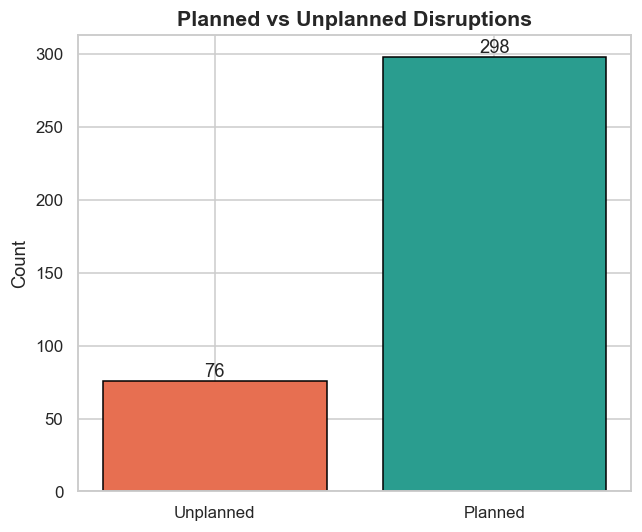

In [33]:
planned_counts = disruption["Planned"].value_counts()

plt.figure(figsize=(6,5))
bars = plt.bar(["Unplanned", "Planned"],
                [planned_counts.get(False, 0), planned_counts.get(True, 0)],
                color=["#e76f51", "#2a9d8f"], edgecolor="black")
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
              int(bar.get_height()), ha="center", va="bottom")
plt.title("Planned vs Unplanned Disruptions", fontsize=14)
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(
    "Visualizations/planned_vs_unplanned_distruptions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

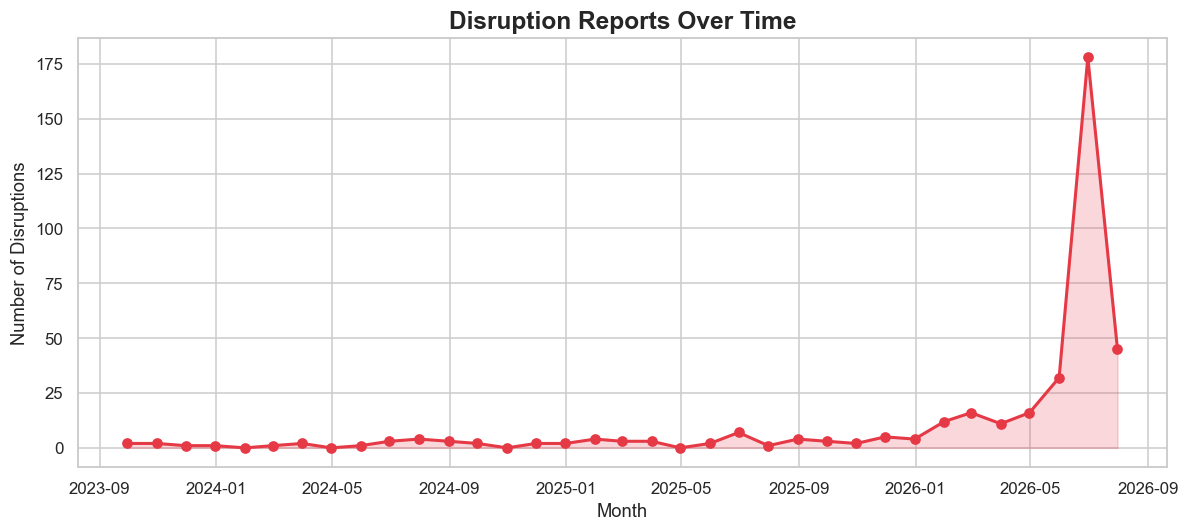

In [34]:
disruption["CreationTime"] = pd.to_datetime(disruption["CreationTime"], format="mixed")
monthly = disruption.set_index("CreationTime").resample("ME").size()

plt.figure(figsize=(11,5))
plt.plot(monthly.index, monthly.values, marker="o", linewidth=2, color="#e63946")
plt.fill_between(monthly.index, monthly.values, alpha=0.2, color="#e63946")
plt.title("Disruption Reports Over Time", fontsize=16)
plt.xlabel("Month"); plt.ylabel("Number of Disruptions")
plt.tight_layout()
plt.savefig(
    "Visualizations/disruption_reports_over_time.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

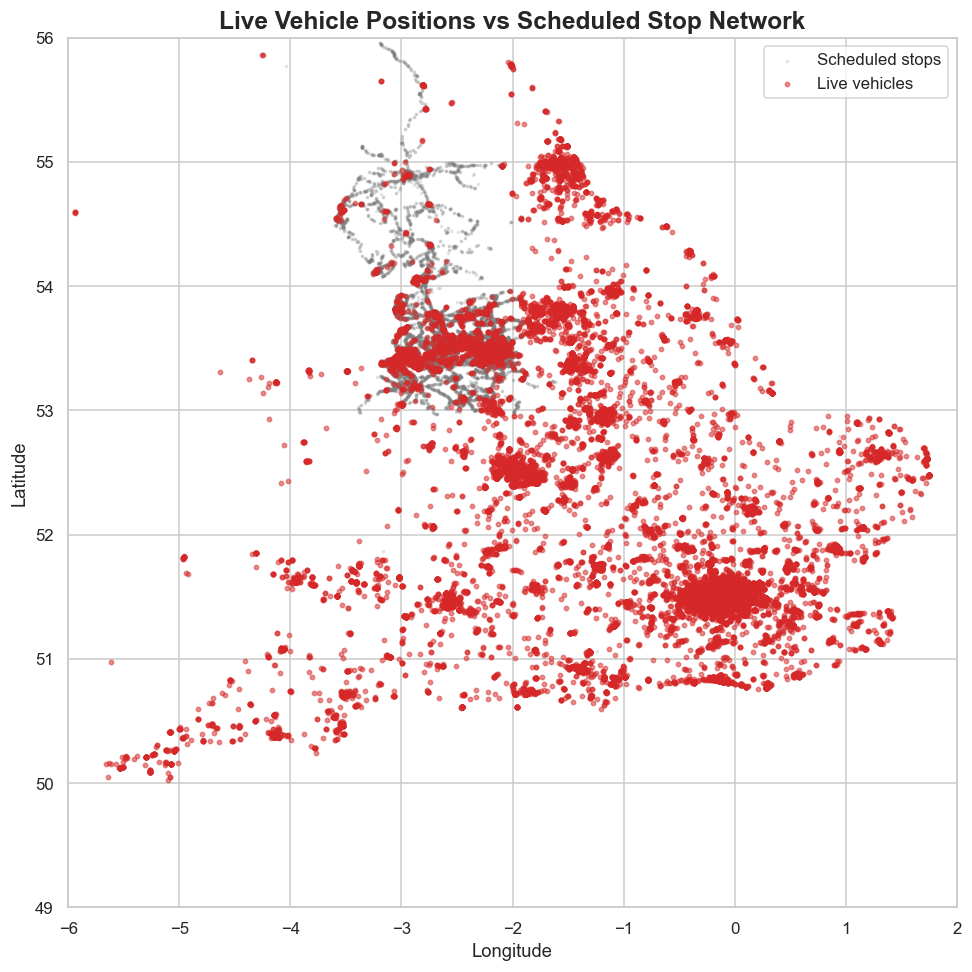

In [35]:
stops_pd = stops.select("stop_lat", "stop_lon").toPandas()
stops_pd["stop_lat"] = stops_pd["stop_lat"].astype(float)
stops_pd["stop_lon"] = stops_pd["stop_lon"].astype(float)

plt.figure(figsize=(9,9))
plt.scatter(stops_pd["stop_lon"], stops_pd["stop_lat"], s=2, alpha=0.15, color="grey", label="Scheduled stops")
plt.scatter(vehicle["Longitude"], vehicle["Latitude"], s=8, alpha=0.5, color="#d62828", label="Live vehicles")
plt.xlim(-6, 2); plt.ylim(49, 56)
plt.title("Live Vehicle Positions vs Scheduled Stop Network", fontsize=16)
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.savefig(
    "Visualizations/live_vehicle_positions_vs_scheduled_stop_network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

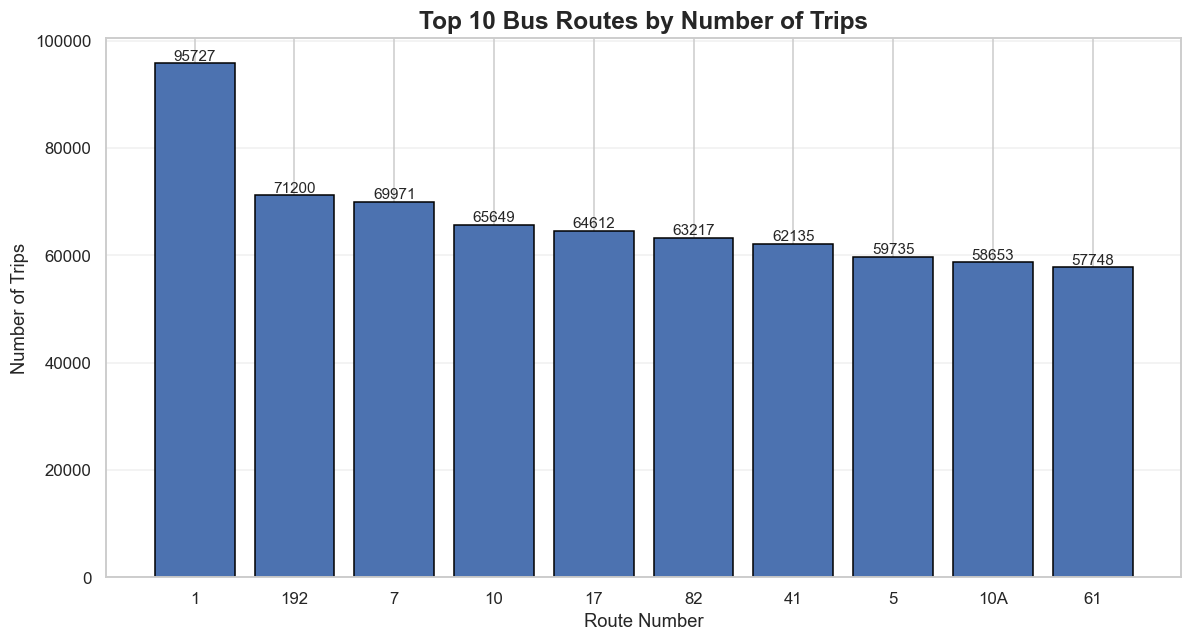

In [36]:
plt.figure(figsize=(11,6))
bars = plt.bar(
    top_routes["route_short_name"],
    top_routes["total_trips"],
    edgecolor="black"
)
plt.title("Top 10 Bus Routes by Number of Trips", fontsize=16, weight="bold")
plt.xlabel("Route Number")
plt.ylabel("Number of Trips")
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    "Visualizations/top_bus_routes_by_trips.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

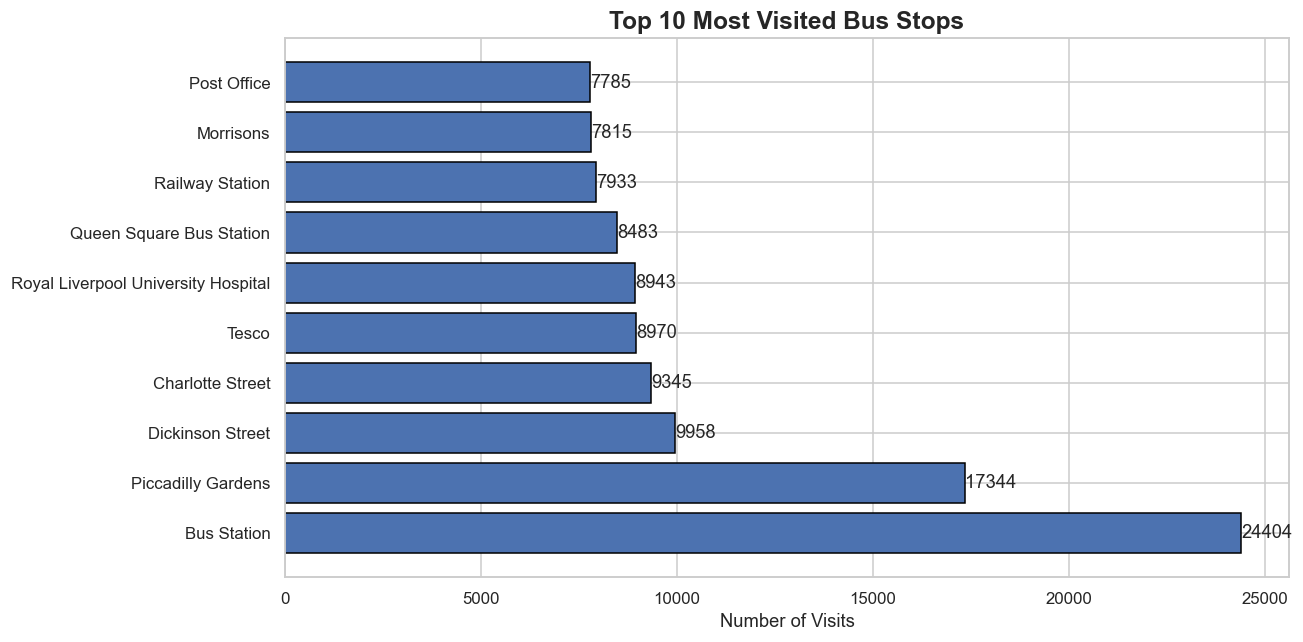

In [44]:
top_stops = top_stops.toPandas()
plt.figure(figsize=(12,6))
bars = plt.barh(
    top_stops["stop_name"],
    top_stops["total_visits"],
    edgecolor="black"
)
plt.title("Top 10 Most Visited Bus Stops", fontsize=16, weight="bold")
plt.xlabel("Number of Visits")
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y()+bar.get_height()/2,
        int(bar.get_width()),
        va="center"
    )
plt.tight_layout()
plt.savefig(
    "Visualizations/most_visited_bus_stops.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

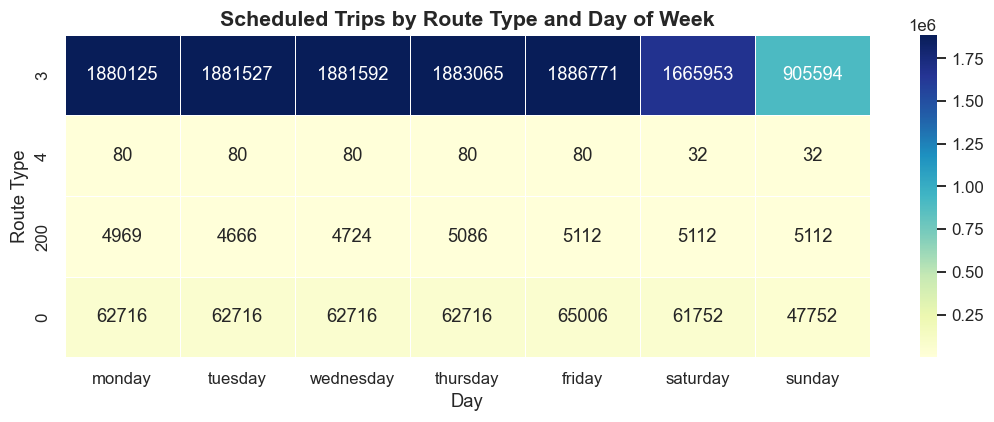

In [45]:
weekday_cols = ["monday","tuesday","wednesday","thursday","friday","saturday","sunday"]
heat_data = bus_schedule.groupBy("route_type").agg(*[sum(c).alias(c) for c in weekday_cols]).toPandas()
heat_data = heat_data.set_index("route_type")

plt.figure(figsize=(10,4))
sns.heatmap(heat_data, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=0.5)
plt.title("Scheduled Trips by Route Type and Day of Week", fontsize=14)
plt.xlabel("Day"); plt.ylabel("Route Type")
plt.tight_layout()
plt.savefig(
    "Visualizations/Days_vs_route_type_scheduledTrips",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

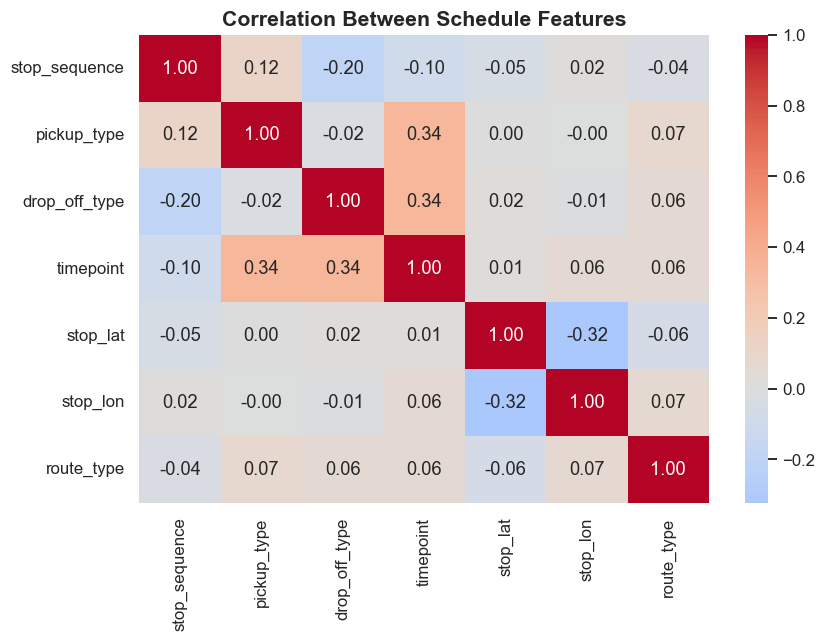

In [46]:
numeric_cols = ["stop_sequence", "pickup_type", "drop_off_type", "timepoint",
                 "stop_lat", "stop_lon", "route_type"]
corr_pd = bus_schedule.select(numeric_cols).sample(fraction=0.05, seed=42).toPandas()

plt.figure(figsize=(8,6))
sns.heatmap(corr_pd.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Between Schedule Features", fontsize=14)
plt.tight_layout()
plt.savefig(
    "Visualizations/correlation",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Delay calculated

In [54]:
from pyspark.sql.functions import radians, sin, cos, atan2, sqrt, hour, minute, second, split
from pyspark.sql import Window
from pyspark.sql.functions import row_number, to_timestamp, col, abs as sabs

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

candidates = matched.join(
    bus_schedule.drop("agency_id", "route_short_name", "route_long_name", "route_type"),
    "route_id"
)
candidates = candidates.withColumn(
    "distance_km",
    haversine(candidates.Latitude, candidates.Longitude,
              candidates.stop_lat, candidates.stop_lon)
)
candidates = candidates.filter(col("distance_km") <= 0.3)

candidates = candidates.withColumn("RecordedTime_ts", to_timestamp("RecordedTime"))
candidates = candidates.withColumn(
    "recorded_secs",
    hour("RecordedTime_ts")*3600 + minute("RecordedTime_ts")*60 + second("RecordedTime_ts")
)

time_parts = split(col("arrival_time"), ":")
candidates = candidates.withColumn(
    "scheduled_secs",
    time_parts.getItem(0).cast("int")*3600 +
    time_parts.getItem(1).cast("int")*60 +
    time_parts.getItem(2).cast("int")
)

candidates = candidates.withColumn(
    "time_diff_secs", sabs(col("recorded_secs") - col("scheduled_secs"))
)

In [55]:
# among nearby-in-space candidates, pick the one CLOSEST IN TIME
w = Window.partitionBy("VehicleRef", "RecordedTime").orderBy("time_diff_secs")
nearest_stop = candidates.withColumn("rn", row_number().over(w)).filter("rn = 1")

nearest_stop = nearest_stop.withColumn(
    "delay_min",
    (col("recorded_secs") - col("scheduled_secs")) / 60
)
nearest_stop = nearest_stop.filter(sabs(col("delay_min")) <= 120)
nearest_stop.select("route_id", "VehicleRef", "distance_km", "time_diff_secs", "delay_min").show(10)
print("Rows remaining:", nearest_stop.count())
nearest_stop = nearest_stop.filter(col("time_diff_secs") <= 1800)
print("Rows remaining after tightening:", nearest_stop.count())

+--------+----------+--------------------+--------------+-------------------+
|route_id|VehicleRef|         distance_km|time_diff_secs|          delay_min|
+--------+----------+--------------------+--------------+-------------------+
|   58853|      0718| 0.14606358130490693|          1472|-24.533333333333335|
|   59235|      0720|    0.27921676648527|           131|  2.183333333333333|
|   59235|      0721|  0.1182796920885059|          1548|              -25.8|
|   11706|      1001|0.052998492542399474|          6067|-101.11666666666666|
|   11706|      1003| 0.08055676148854057|           652|-10.866666666666667|
|   11706|      1004| 0.08882219723539683|            94|-1.5666666666666667|
|    1625|     10043|  0.0601114896080825|          1061| 17.683333333333334|
|    6054|     10046|0.022212030910310824|          1454|-24.233333333333334|
|   11706|      1005| 0.03822520432279334|           276|                4.6|
|   11706|      1006| 0.23364429913827442|           807|       

In [56]:

from pyspark.sql.functions import hour as hour_fn

delay_df = nearest_stop.withColumn("hour", hour_fn("RecordedTime_ts"))
delay_pd = delay_df.select("route_id", "VehicleRef", "delay_min", "hour", "agency_id", "RecordedTime").toPandas()
delay_pd["recorded_time"] = pd.to_datetime(delay_pd["RecordedTime"], format="mixed").dt.tz_localize(None)

# disruption times, timezone stripped
disruption["CreationTime"] = pd.to_datetime(disruption["CreationTime"], format="mixed").dt.tz_localize(None)
disruption_times = disruption["CreationTime"].values.astype("datetime64[s]")

def has_nearby_disruption(recorded_time, window_hours=6):
    diffs = np.abs((disruption_times - np.datetime64(recorded_time)).astype("timedelta64[s]").astype(int))
    return int((diffs <= window_hours*3600).any())

delay_pd["disruption_active"] = delay_pd["recorded_time"].apply(has_nearby_disruption)
print(delay_pd["disruption_active"].value_counts())
delay_pd.head()

disruption_active
1    713
0    300
Name: count, dtype: int64


,route_id,VehicleRef,delay_min,hour,agency_id,RecordedTime,recorded_time,disruption_active
0,58853,0718,-24.533333,21,OP258,2026-07-02 16:01:28+00:00,2026-07-02 16:01:28,1
1,59235,0720,2.183333,23,OP258,2026-07-02 17:23:11+00:00,2026-07-02 17:23:11,1
2,59235,0721,-25.800000,23,OP258,2026-07-02 17:16:12+00:00,2026-07-02 17:16:12,1
3,11706,1003,-10.866667,22,OP6,2026-07-02 16:48:08+00:00,2026-07-02 16:48:08,1
4,11706,1004,-1.566667,22,OP6,2026-07-02 16:27:26+00:00,2026-07-02 16:27:26,1


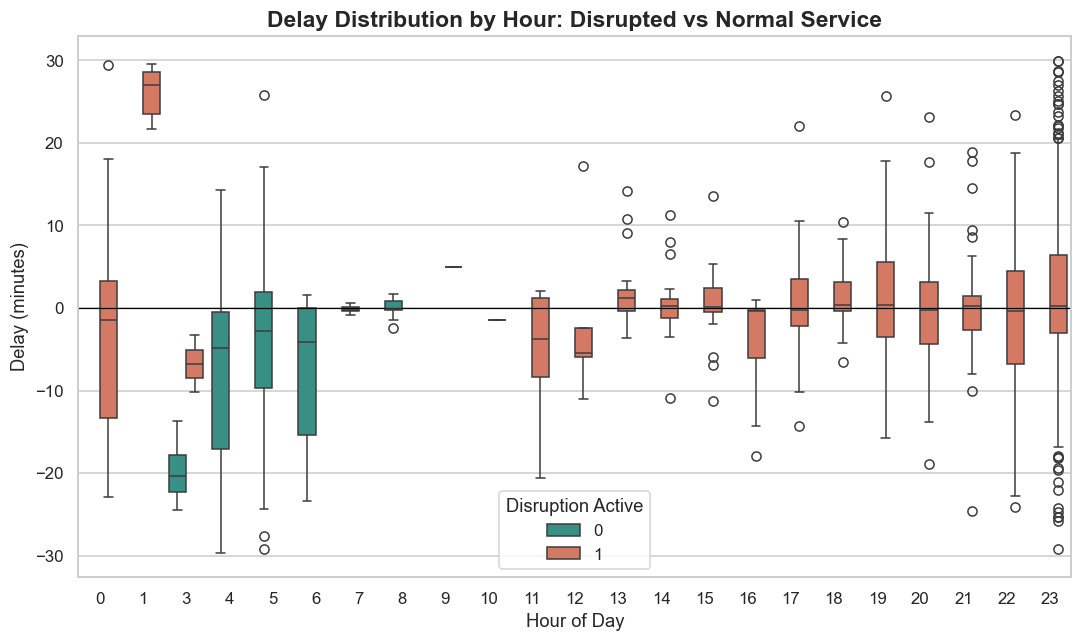

,mean,median,std,count
disruption_active,,,,
0,-5.542778,-3.016667,10.033780,300
1,0.756615,0.116667,9.427082,713


In [58]:
# once delay_min and a disruption_active flag exist:
plt.figure(figsize=(10,6))
sns.boxplot(data=delay_pd, x="hour", y="delay_min", hue="disruption_active",
            palette={0:"#2a9d8f", 1:"#e76f51"})
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Delay Distribution by Hour: Disrupted vs Normal Service", fontsize=15)
plt.xlabel("Hour of Day"); plt.ylabel("Delay (minutes)")
plt.legend(title="Disruption Active")
plt.tight_layout()
plt.savefig("Visualizations/delay_by_hour_disruption.png", dpi=300, bbox_inches="tight")
plt.show()
delay_pd.groupby("disruption_active")["delay_min"].agg(["mean", "median", "std", "count"])

In [59]:
delay_pd_full = nearest_stop.select("distance_km", "time_diff_secs", "delay_min").toPandas()
print(delay_pd_full[["distance_km","time_diff_secs","delay_min"]].corr())

                distance_km  time_diff_secs  delay_min
distance_km        1.000000       -0.027195  -0.074321
time_diff_secs    -0.027195        1.000000  -0.137716
delay_min         -0.074321       -0.137716   1.000000


In [61]:
final_features = nearest_stop.withColumn("hour", hour_fn("RecordedTime_ts")).select(
    "route_id", "agency_id", "hour", "distance_km", "time_diff_secs", "delay_min"
)
final_features.write.mode("overwrite").parquet("Data/Processed/model_features")
print("Saved:", final_features.count(), "rows")

Saved: 1013 rows
